
                                                                           
   # <center>Covid-19 in USA </center>               
   
 # <center>by Ida Tateo</center>



1. Define the Research problem and associated questions.
2. Analyze the data by descriptive statistics and graphical visualization.
3. Prepare the data by using relevant preprocessing transformations, data cleaning, 
    data standardization, deaing with null and outlier values.

    

## 1. Define the Research problem and questions

**Research Questions:**  

    1.Create Sand Layer Charts to detect patterns of Covid-19 trends in the USA from the beginning of the pandemic to December 2020.

**Data Source:**
    https://raw.githubusercontent.com/nytimes/covid-19-data/master/us-states.csv


In [23]:
# Import required packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors
import colorsys
import seaborn as sns



## 2. Analyze the data using descriptive statistics and graphical visualizations.

In [25]:
# filter warnings 
import warnings
warnings.filterwarnings('ignore')

# load NYT state-level data
url = "https://raw.githubusercontent.com/nytimes/covid-19-data/master/us-states.csv"
covid_usa = pd.read_csv(url, parse_dates=["date"])

# filter for 2020 only
covid_usa = covid_usa[covid_usa['date'].dt.year == 2020]

# change NaN to 0
covid_usa = covid_usa.replace(["NaN", "nan", "NA", "N/A", "", None], np.nan).fillna(0)

# print the shape and first 5 rows.
print(covid_usa.shape)
print(covid_usa.head())



(16734, 5)
        date       state  fips  cases  deaths
0 2020-01-21  Washington    53      1       0
1 2020-01-22  Washington    53      1       0
2 2020-01-23  Washington    53      1       0
3 2020-01-24    Illinois    17      1       0
4 2020-01-24  Washington    53      1       0


In [26]:
# Print the datatypes which are keys.
types = covid_usa.dtypes
print(types)
print("Keys of Covid in the USA dataset:\n", covid_usa.keys())

date      datetime64[ns]
state             object
fips               int64
cases              int64
deaths             int64
dtype: object
Keys of Covid in the USA dataset:
 Index(['date', 'state', 'fips', 'cases', 'deaths'], dtype='object')


(346, 55)
state       Alabama  Alaska  Arizona  Arkansas  California  Colorado  \
date                                                                   
2020-01-21      0.0     0.0      0.0       0.0         0.0       0.0   
2020-01-22      0.0     0.0      0.0       0.0         0.0       0.0   
2020-01-23      0.0     0.0      0.0       0.0         0.0       0.0   
2020-01-24      0.0     0.0      0.0       0.0         0.0       0.0   
2020-01-25      0.0     0.0      0.0       0.0         1.0       0.0   

state       Connecticut  Delaware  District of Columbia  Florida  ...  \
date                                                              ...   
2020-01-21          0.0       0.0                   0.0      0.0  ...   
2020-01-22          0.0       0.0                   0.0      0.0  ...   
2020-01-23          0.0       0.0                   0.0      0.0  ...   
2020-01-24          0.0       0.0                   0.0      0.0  ...   
2020-01-25          0.0       0.0              

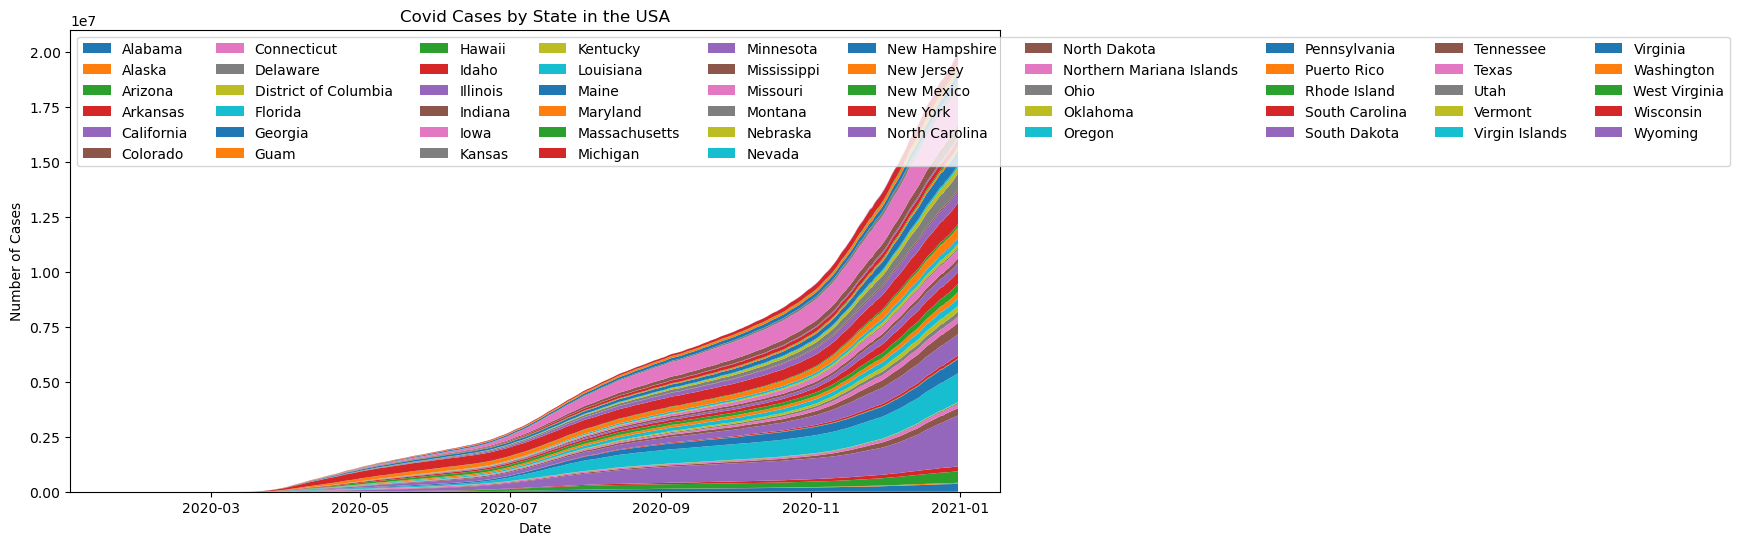

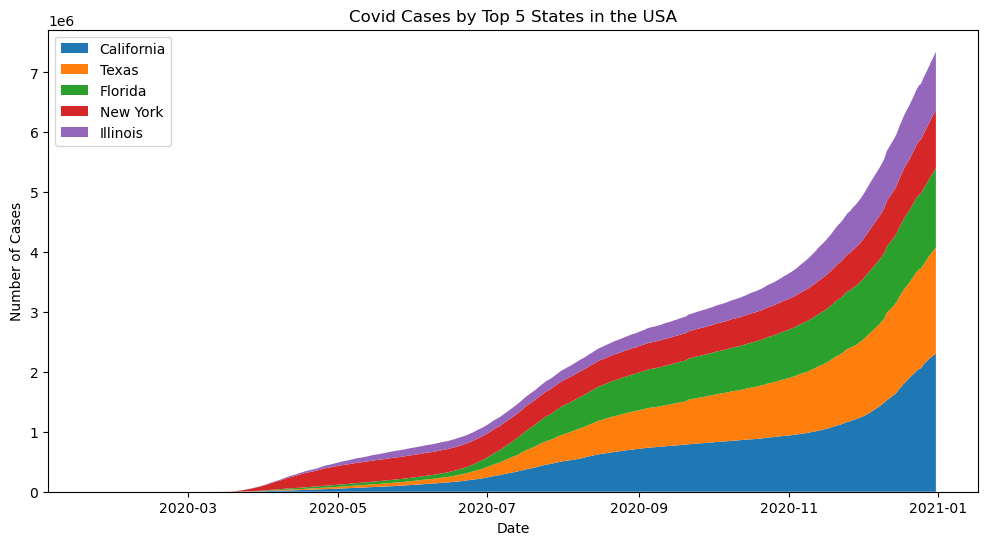

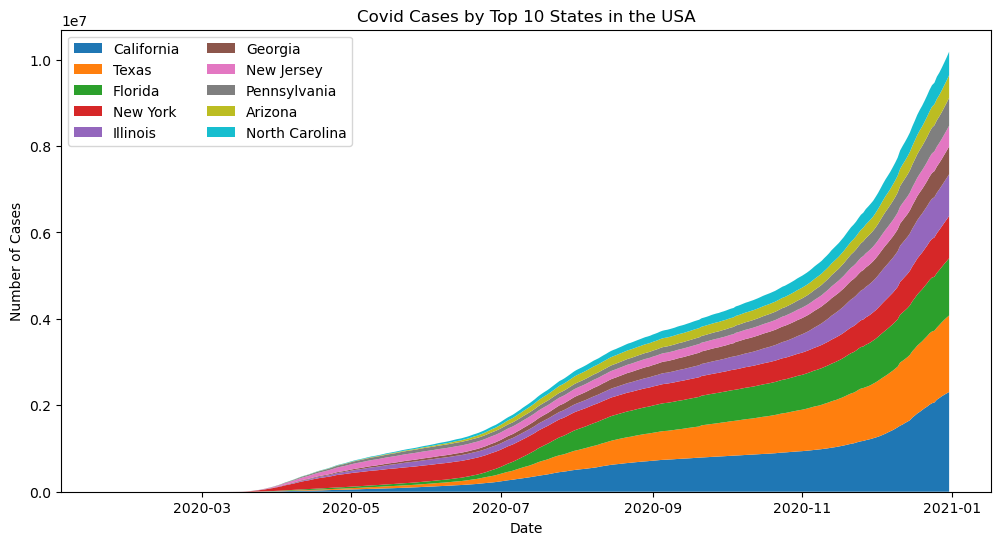

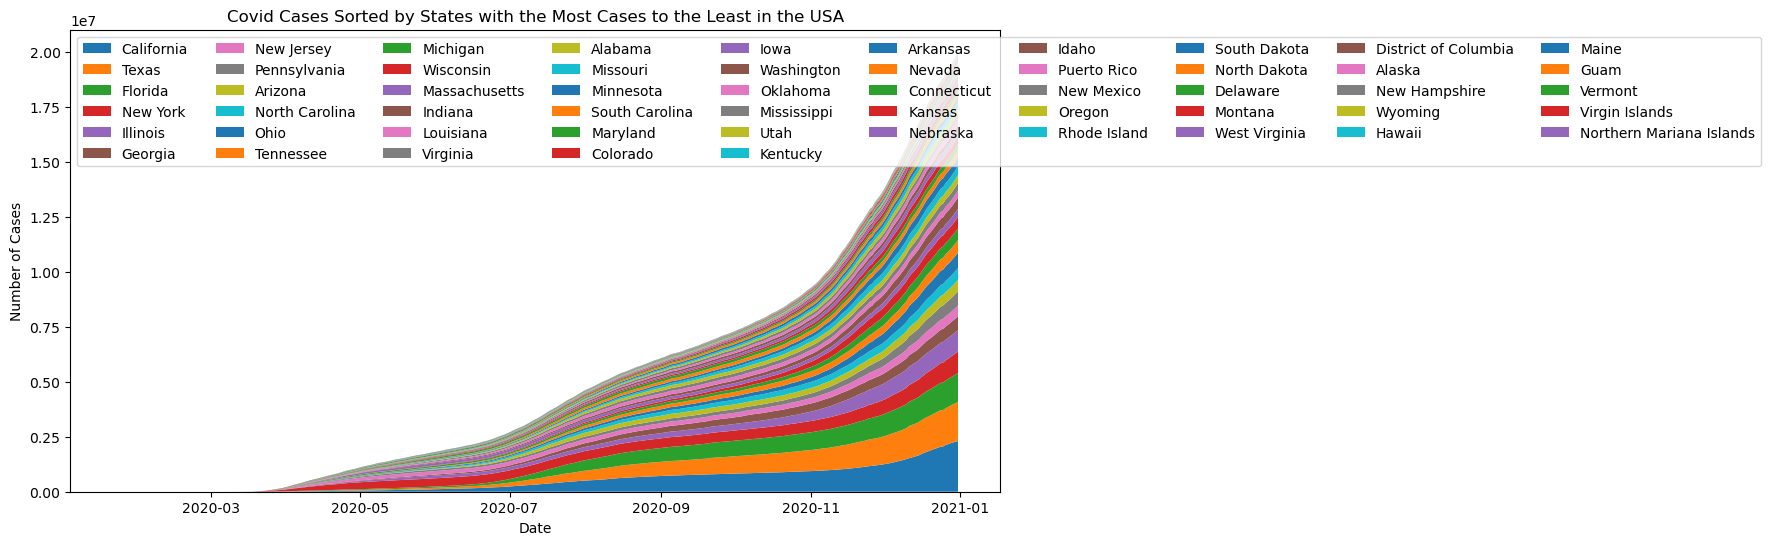

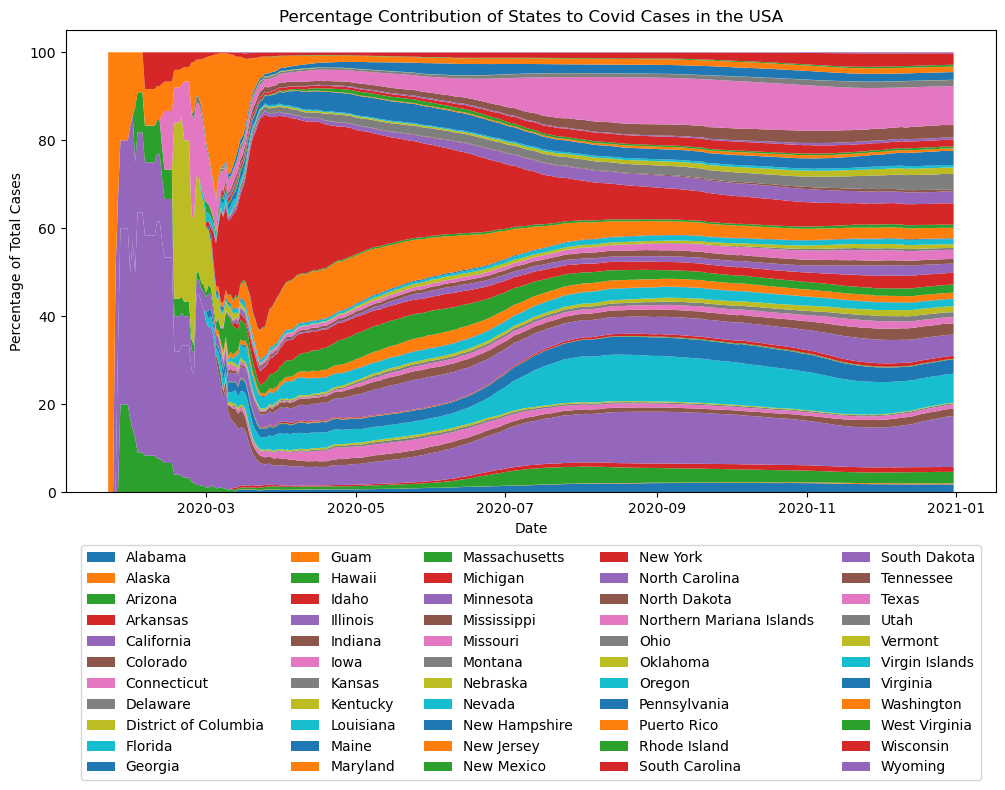

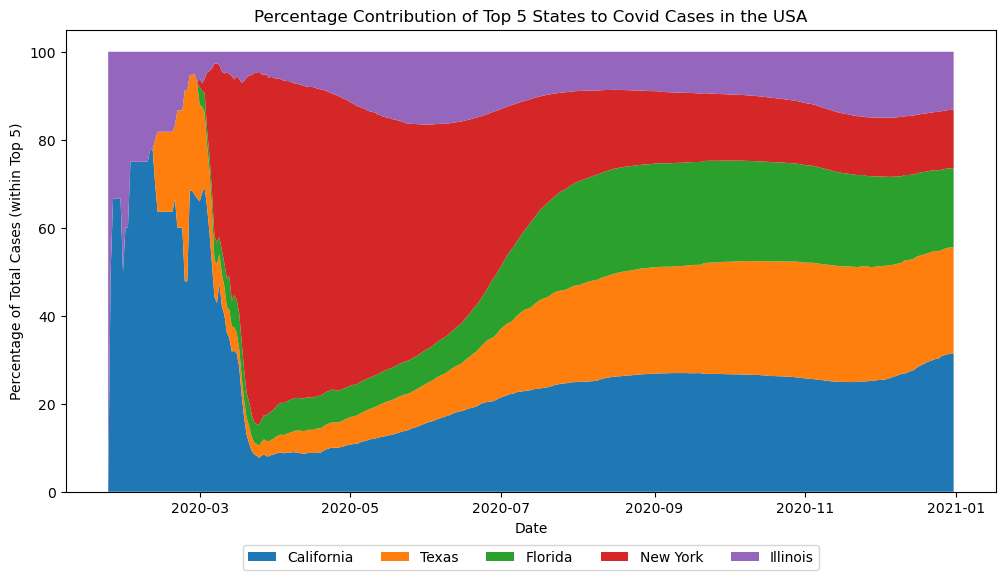

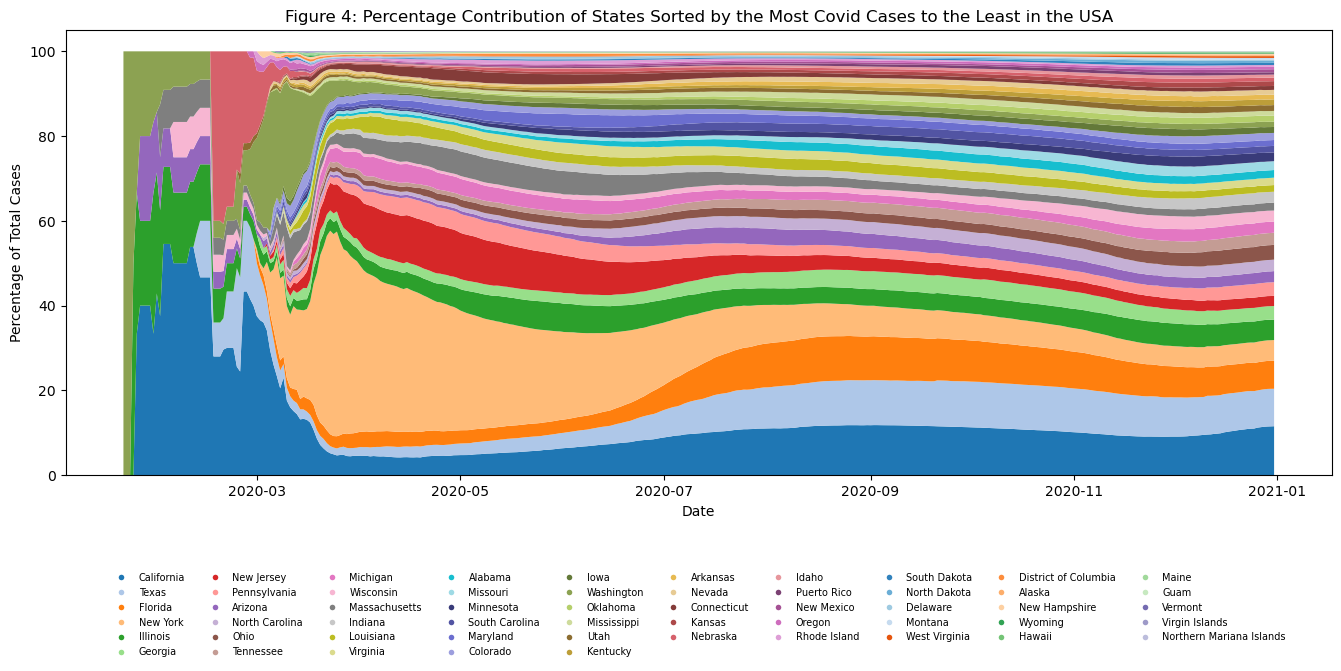

In [28]:

# create a covid dataset with date, state, and cases
covid_usa_cases = covid_usa[['date', 'cases', 'state']]

# pivot so each state is a column, values = cumulative cases
pivot_covid_usa_cases = covid_usa_cases.pivot(index="date", columns="state", values="cases")

# change date index to datetime.
pivot_covid_usa_cases.index=pd.to_datetime(pivot_covid_usa_cases.index)

# change NaN to 0
pivot_covid_usa_cases = pivot_covid_usa_cases.replace(["NaN", "nan", "NA", "N/A", "", None], np.nan).fillna(0)

print(pivot_covid_usa_cases.shape)
print(pivot_covid_usa_cases.head())
print(pivot_covid_usa_cases.tail())
print(pivot_covid_usa_cases.describe().T)

# create stackplot
plt.figure(figsize=(12,6))
plt.stackplot(pivot_covid_usa_cases.index,
              pivot_covid_usa_cases.T,
              labels=pivot_covid_usa_cases.columns)
plt.title("Covid Cases by State in the USA")
plt.ylabel("Number of Cases")
plt.xlabel("Date")
plt.legend(loc="upper left", ncol=10)
plt.show()

# select the top 5 States in the USA with the most cases

# find the total cases per state
state_totals=pivot_covid_usa_cases.sum().sort_values(ascending=False)

# select the top 5 regions
top5_states=state_totals.head(5).index

# filter dataframe to those regions only
top5_data=pivot_covid_usa_cases[top5_states]

# create stackplot
plt.figure(figsize=(12,6))
plt.stackplot(top5_data.index,
              top5_data.T,
              labels=top5_data.columns)
plt.title("Covid Cases by Top 5 States in the USA")
plt.ylabel("Number of Cases")
plt.xlabel("Date")
plt.legend(loc="upper left")
plt.show()

# select top 10 states in the USA with the most cases

# select the top 10 states
top10_states=state_totals.head(10).index

# filter dataframe to those regions only
top10_data=pivot_covid_usa_cases[top10_states]

# create stackplot
plt.figure(figsize=(12,6))
plt.stackplot(top10_data.index,
              top10_data.T,
              labels=top10_data.columns)
plt.title("Covid Cases by Top 10 States in the USA")
plt.ylabel("Number of Cases")
plt.xlabel("Date")
plt.legend(loc="upper left", ncol=2)
plt.show()

# sort the states in the USA with the most cases to the least

# select sorted states
sorted_states=state_totals.head(55).index

# filter dataframe to sorted states
sorted_data=pivot_covid_usa_cases[sorted_states]

# create stackplot
plt.figure(figsize=(12,6))
plt.stackplot(sorted_data.index,
              sorted_data.T,
              labels=sorted_data.columns)
plt.title("Covid Cases Sorted by States with the Most Cases to the Least in the USA")
plt.ylabel("Number of Cases")
plt.xlabel("Date")
plt.legend(loc="upper left", ncol=10)
plt.show()

# convert to percentages per day
covid_percent = pivot_covid_usa_cases.div(pivot_covid_usa_cases.sum(axis=1), axis=0) * 100

# create stackplot
plt.figure(figsize=(12,6))
plt.stackplot(covid_percent.index,
              covid_percent.T,
              labels=covid_percent.columns)
plt.title("Percentage Contribution of States to Covid Cases in the USA")
plt.ylabel("Percentage of Total Cases")
plt.xlabel("Date")
plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=5)
plt.show()

# select the top N regions
N = 5
state_totals=pivot_covid_usa_cases.sum().sort_values(ascending=False)
topN_states =state_totals.head(N).index

# Filter only top N regions
topN_percent = pivot_covid_usa_cases[topN_states]

# Normalize to percent contribution among top N
topN_percent = topN_percent.div(topN_percent.sum(axis=1), axis=0) * 100

plt.figure(figsize=(12,6))
plt.stackplot(topN_percent.index,
              topN_percent.T,
              labels=topN_percent.columns)

plt.title(f"Percentage Contribution of Top {N} States to Covid Cases in the USA")
plt.ylabel("Percentage of Total Cases (within Top 5)")
plt.xlabel("Date")
plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=5)
plt.show()

# select the top N states
#N = 55
#state_totals=pivot_covid_usa_cases.sum().sort_values(ascending=False)
#topN_states =state_totals.head(N).index

# Filter only top N states
#topN_percent = pivot_covid_usa_cases[topN_states]

# Normalize to percent contribution among top N
#topN_percent = topN_percent.div(topN_percent.sum(axis=1), axis=0) * 100

# --- UNIQUE COLORS ---
#n_states = len(topN_states)
#cmap = cm.get_cmap("tab20", n_states)   # you may also use "tab20b" or "tab20c"
#colors = [cmap(i) for i in range(n_states)]

#plt.figure(figsize=(12, 6))

# --- GLASBEY COLOR MAP (256 distinct categorical colors) ---
#cmap = cm.get_cmap("glasbey", N)
#colors = [cmap(i) for i in range(N)]

#custom_colors_55 = [
#   "#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd",
#   "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22", "#17becf",
#   "#393b79", "#5254a3", "#6b6ecf", "#9c9ede", "#637939",
#   "#8ca252", "#b5cf6b", "#cedb9c", "#8c6d31", "#bd9e39",
#   "#e7ba52", "#e7cb94", "#843c39", "#ad494a", "#d6616b",
#   "#e7969c", "#7b4173", "#a55194", "#ce6dbd", "#de9ed6",
#   "#3182bd", "#6baed6", "#9ecae1", "#c6dbef", "#e6550d",
#   "#fd8d3c", "#fdae6b", "#fdd0a2", "#31a354", "#74c476",
#   "#a1d99b", "#c7e9c0", "#756bb1", "#9e9ac8", "#bcbddc",
#   "#dadaeb", "#636363", "#969696", "#bdbdbd", "#d9d9d9",
#   "#f03b20", "#feb24c", "#ffeda0"
#]

#N = 55

# Use only the first N custom colors
#colors = custom_colors_55[:N]

# ----------------- helper: generate N distinct colors -----------------
#def generate_distinct_colors(n):
#    """
#    Generate n visually distinct hex colors using evenly spaced hues.
#    """
#    colors = []
#    for i in range(n):
#        h = i / n                 # hue
#        s = 0.65                  # saturation
#        v = 0.9                   # value (brightness)
#        r, g, b = colorsys.hsv_to_rgb(h, s, v)
#        colors.append(mcolors.to_hex((r, g, b)))
#    return colors

# -------- helper to get many distinct categorical colors ----------
def get_many_tab20_colors(n_needed):
    base_colors = []
    for cmap_name in ["tab20", "tab20b", "tab20c"]:
        cmap = cm.get_cmap(cmap_name)
        # 20 discrete entries in each tab20* map
        for i in range(20):
            base_colors.append(cmap(i / 19.0))
    return base_colors[:n_needed]

# select the top N states
N = 55
state_totals=pivot_covid_usa_cases.sum().sort_values(ascending=False)
topN_states =state_totals.head(N).index

# Filter only top N states
topN_percent = pivot_covid_usa_cases[topN_states]

# Normalize to percent contribution among top N
topN_percent = topN_percent.div(topN_percent.sum(axis=1), axis=0) * 100

# get one distinct color per state
n_states = len(topN_states)
colors = get_many_tab20_colors(n_states)

# generate EXACTLY one color per state
#n_states = len(topN_states)
#colors = generate_distinct_colors(n_states)

plt.figure(figsize=(14, 7))

plt.stackplot(topN_percent.index,
              topN_percent.T,
              labels=topN_percent.columns,
              colors=colors)

plt.title("Figure 4: Percentage Contribution of States Sorted by the Most Covid Cases to the Least in the USA")
plt.ylabel("Percentage of Total Cases")
plt.xlabel("Date")

# dot-style legend, using zip instead of indexing
handles = [
    Line2D(
        [0], [0],
        marker='o',
        linestyle='None',
        markerfacecolor=color,
        markeredgecolor='none',
        markersize=4,
        label=state
    )
    for state, color in zip(topN_states, colors)
]

plt.legend(
    handles=handles,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.2),
    ncol=10,
    fontsize=7,
    frameon=False
)


# --- DOT-STYLE LEGEND PROXY HANDLES ---
#handles = [
#    Line2D(
#        [0], [0],
#        marker='o',
#        linestyle='None',
#        markerfacecolor=colors[i],
#        markeredgecolor='none',
#        markersize=4,      # make the dot smaller or larger here
#        label=state
#    )
#    for i, state in enumerate(topN_states)
#]

#plt.legend(handles=handles,
#           loc="upper center",
#           bbox_to_anchor=(0.5, -0.1),
#           ncol=10,
#           frameon=False,
#           fontsize=8)

# SAVE PNG FOR PUBLICATION
plt.savefig("figure4_usa_covid_cases_percentage_sorted.png", dpi=600, bbox_inches="tight")

plt.tight_layout()
plt.show()


(346, 55)
state       Alabama  Alaska  Arizona  Arkansas  California  Colorado  \
date                                                                   
2020-01-21      0.0     0.0      0.0       0.0         0.0       0.0   
2020-01-22      0.0     0.0      0.0       0.0         0.0       0.0   
2020-01-23      0.0     0.0      0.0       0.0         0.0       0.0   
2020-01-24      0.0     0.0      0.0       0.0         0.0       0.0   
2020-01-25      0.0     0.0      0.0       0.0         0.0       0.0   

state       Connecticut  Delaware  District of Columbia  Florida  ...  \
date                                                              ...   
2020-01-21          0.0       0.0                   0.0      0.0  ...   
2020-01-22          0.0       0.0                   0.0      0.0  ...   
2020-01-23          0.0       0.0                   0.0      0.0  ...   
2020-01-24          0.0       0.0                   0.0      0.0  ...   
2020-01-25          0.0       0.0              

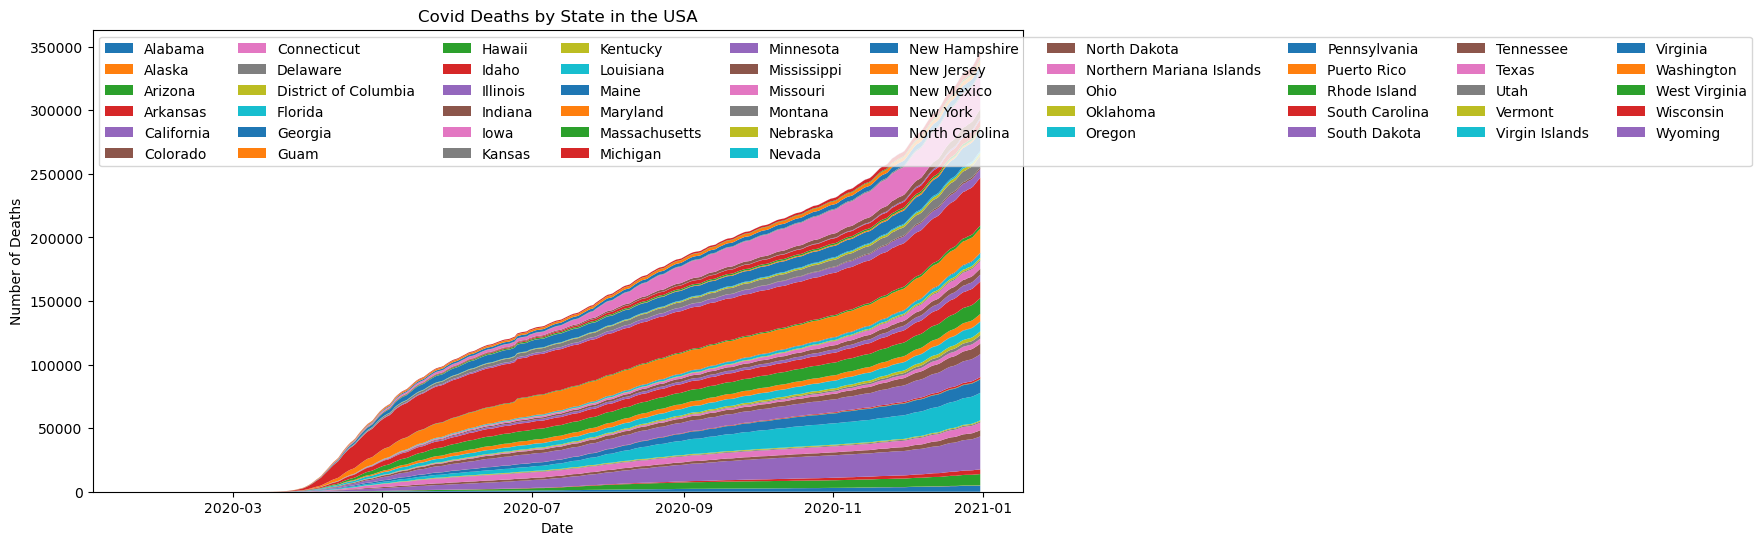

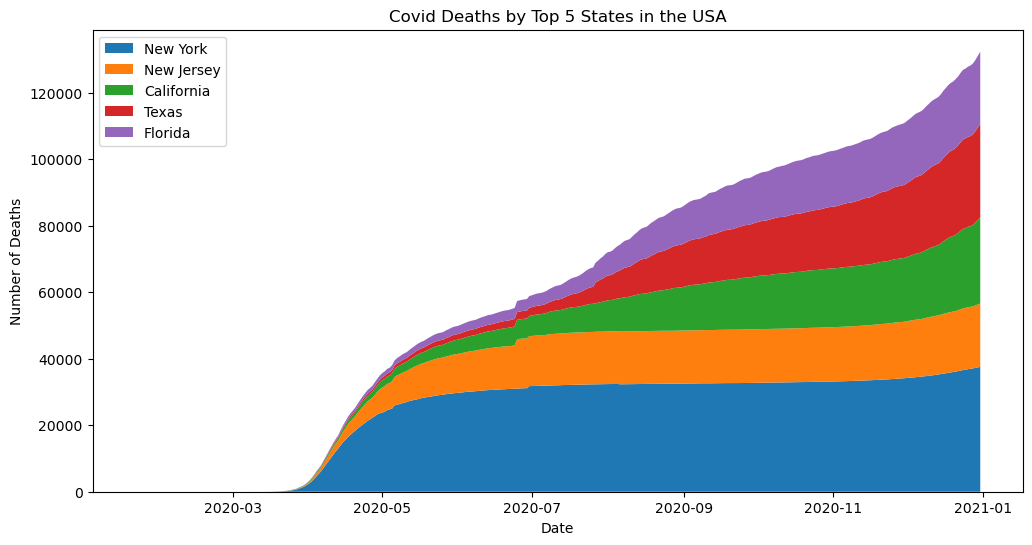

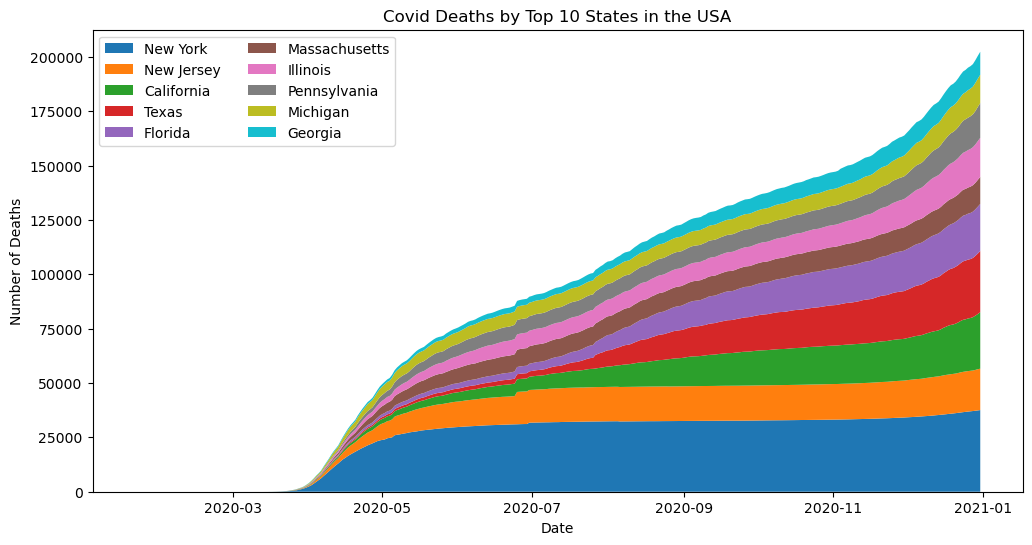

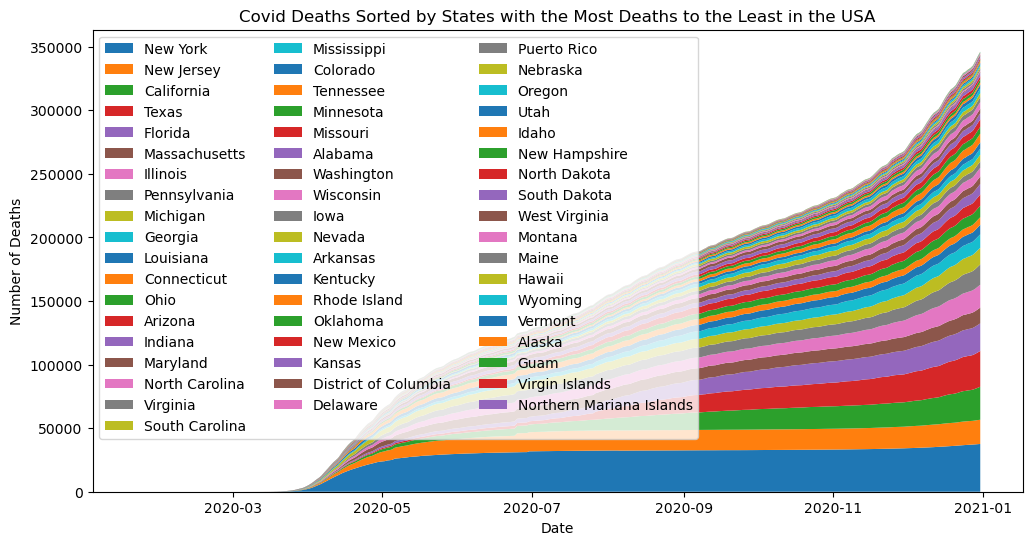

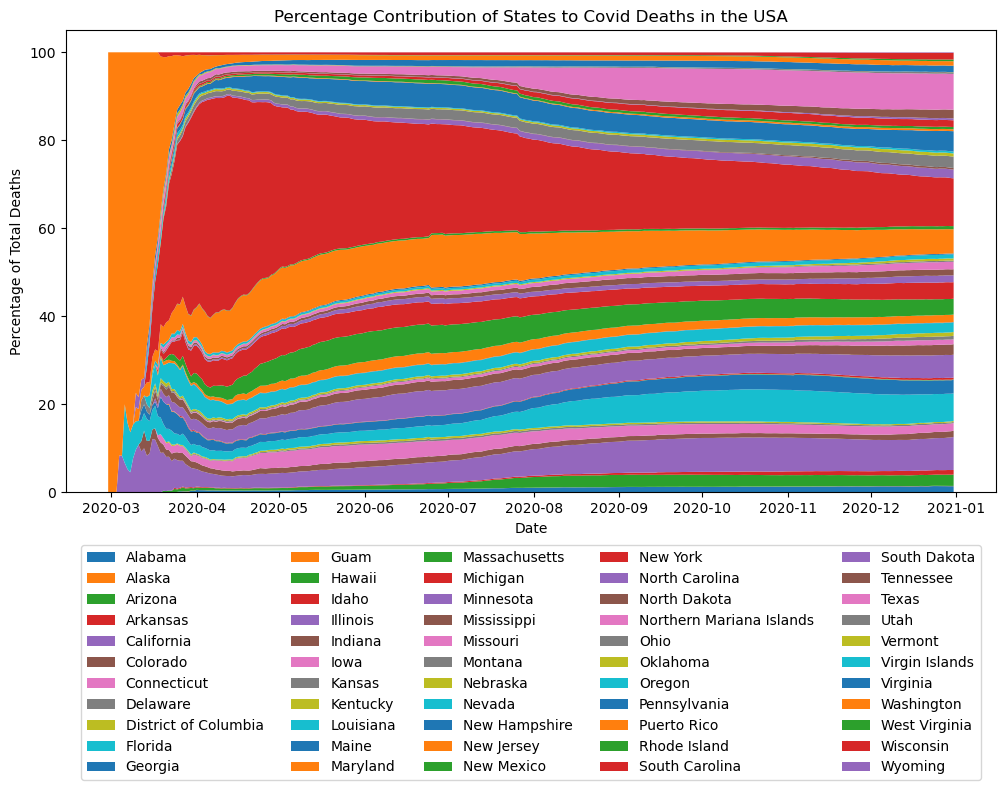

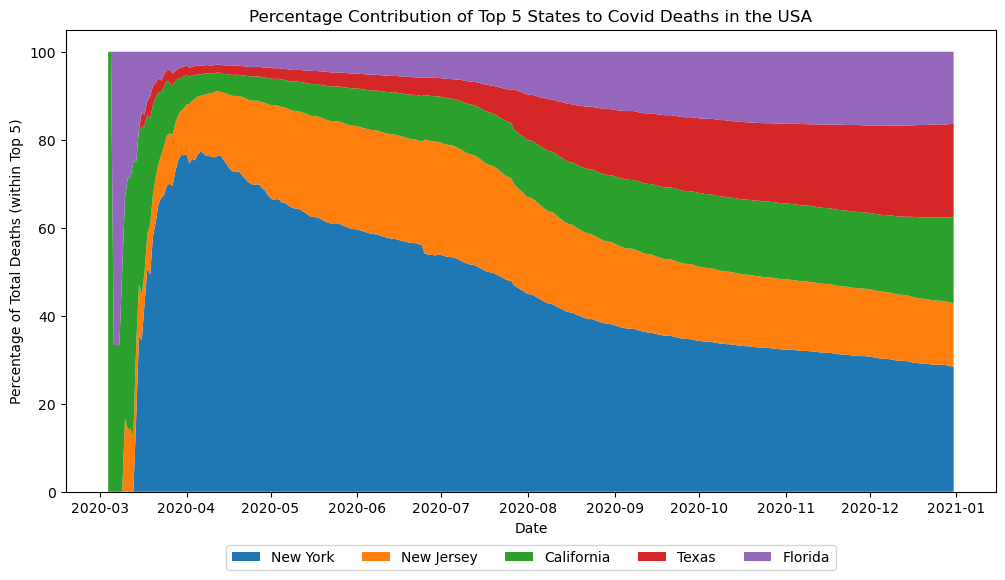

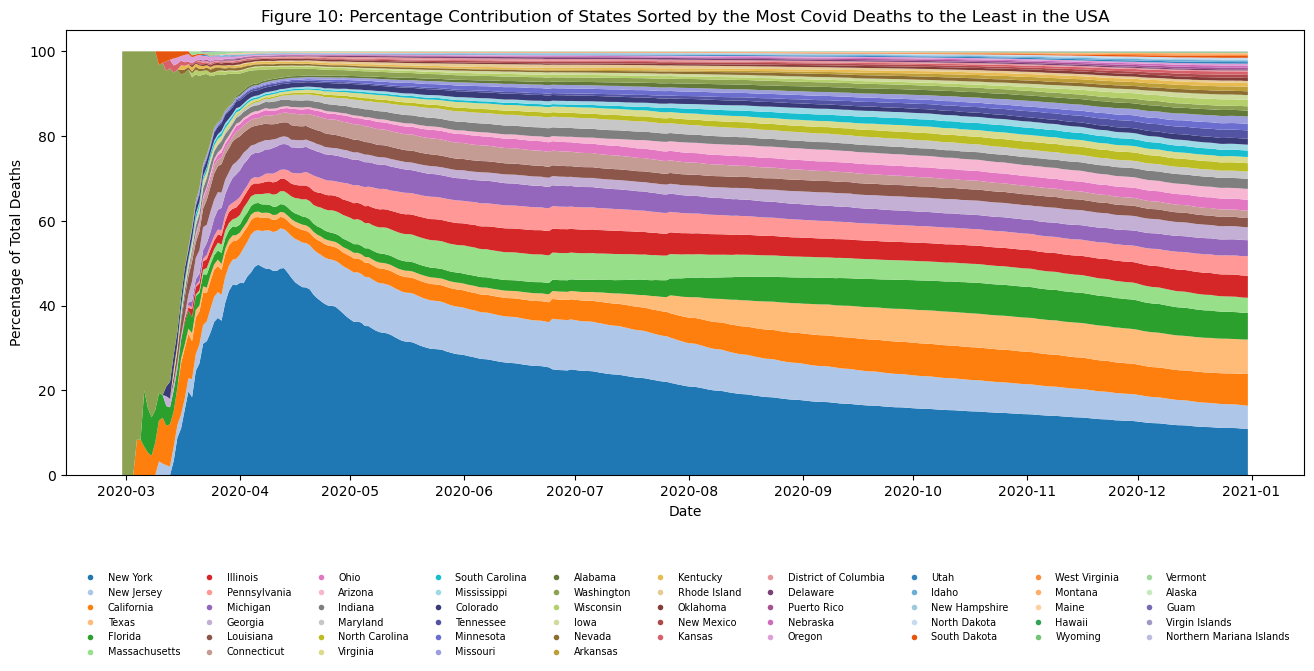

In [29]:
# create a covid dataset with date, state, and deaths
covid_usa_deaths = covid_usa[['date', 'deaths', 'state']]

# pivot so each state is a column, values = cumulative deaths
pivot_covid_usa_deaths = covid_usa_deaths.pivot(index="date", columns="state", values="deaths")

# change date index to datetime.
pivot_covid_usa_deaths.index=pd.to_datetime(pivot_covid_usa_deaths.index)

# change NaN to 0
pivot_covid_usa_deaths = pivot_covid_usa_deaths.replace(["NaN", "nan", "NA", "N/A", "", None], np.nan).fillna(0)

print(pivot_covid_usa_deaths.shape)
print(pivot_covid_usa_deaths.head())
print(pivot_covid_usa_deaths.tail())
print(pivot_covid_usa_deaths.describe().T)

# create stackplot
plt.figure(figsize=(12,6))
plt.stackplot(pivot_covid_usa_deaths.index,
              pivot_covid_usa_deaths.T,
              labels=pivot_covid_usa_deaths.columns)
plt.title("Covid Deaths by State in the USA")
plt.ylabel("Number of Deaths")
plt.xlabel("Date")
plt.legend(loc="upper left", ncol=10)
plt.show()

# select the top 5 states in the USA with the most deaths

# find the total deaths per state
state_totals=pivot_covid_usa_deaths.sum().sort_values(ascending=False)

# select the top 5 states
top5_states=state_totals.head(5).index

# filter dataframe to those regions only
top5_data=pivot_covid_usa_deaths[top5_states]

# create stackplot
plt.figure(figsize=(12,6))
plt.stackplot(top5_data.index,
              top5_data.T,
              labels=top5_data.columns)
plt.title("Covid Deaths by Top 5 States in the USA")
plt.ylabel("Number of Deaths")
plt.xlabel("Date")
plt.legend(loc="upper left")
plt.show()

# select top 10 states in the USA with the most deaths

# select the top 10 states
top10_states=state_totals.head(10).index

# filter dataframe to those regions only
top10_data=pivot_covid_usa_deaths[top10_states]

# create stackplot
plt.figure(figsize=(12,6))
plt.stackplot(top10_data.index,
              top10_data.T,
              labels=top10_data.columns)
plt.title("Covid Deaths by Top 10 States in the USA")
plt.ylabel("Number of Deaths")
plt.xlabel("Date")
plt.legend(loc="upper left", ncol=2)
plt.show()

# sort the states in the USA with the most deaths to the least

# select sorted regions
sorted_states=state_totals.head(55).index

# filter dataframe to sorted regions
sorted_data=pivot_covid_usa_deaths[sorted_states]

# create stackplot
plt.figure(figsize=(12,6))
plt.stackplot(sorted_data.index,
              sorted_data.T,
              labels=sorted_data.columns)
plt.title("Covid Deaths Sorted by States with the Most Deaths to the Least in the USA")
plt.ylabel("Number of Deaths")
plt.xlabel("Date")
plt.legend(loc="upper left", ncol=3)
plt.show()

# convert to percentages per day
covid_percent_deaths = pivot_covid_usa_deaths.div(pivot_covid_usa_deaths.sum(axis=1), axis=0) * 100

# create stackplot
plt.figure(figsize=(12,6))
plt.stackplot(covid_percent_deaths.index,
              covid_percent_deaths.T,
              labels=covid_percent_deaths.columns)
plt.title("Percentage Contribution of States to Covid Deaths in the USA")
plt.ylabel("Percentage of Total Deaths")
plt.xlabel("Date")
plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=5)
plt.show()

# select the top N states
N = 5
state_totals=pivot_covid_usa_deaths.sum().sort_values(ascending=False)
topN_states =state_totals.head(N).index

# Filter only top N states
topN_percent = pivot_covid_usa_deaths[topN_states]

# Normalize to percent contribution among top N
topN_percent = topN_percent.div(topN_percent.sum(axis=1), axis=0) * 100

plt.figure(figsize=(12,6))
plt.stackplot(topN_percent.index,
              topN_percent.T,
              labels=topN_percent.columns)

plt.title(f"Percentage Contribution of Top {N} States to Covid Deaths in the USA")
plt.ylabel("Percentage of Total Deaths (within Top 5)")
plt.xlabel("Date")
plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=5)
plt.show()

# -------- helper to get many distinct categorical colors ----------
def get_many_tab20_colors(n_needed):
    base_colors = []
    for cmap_name in ["tab20", "tab20b", "tab20c"]:
        cmap = cm.get_cmap(cmap_name)
        # 20 discrete entries in each tab20* map
        for i in range(20):
            base_colors.append(cmap(i / 19.0))
    return base_colors[:n_needed]

# select the top N states
N = 55
state_totals=pivot_covid_usa_deaths.sum().sort_values(ascending=False)
topN_states =state_totals.head(N).index

# Filter only top N states
topN_percent = pivot_covid_usa_deaths[topN_states]

# Normalize to percent contribution among top N
topN_percent = topN_percent.div(topN_percent.sum(axis=1), axis=0) * 100

# get one distinct color per state
n_states = len(topN_states)
colors = get_many_tab20_colors(n_states)

plt.figure(figsize=(14, 7))

plt.stackplot(topN_percent.index,
              topN_percent.T,
              labels=topN_percent.columns,
              colors=colors)

plt.title("Figure 10: Percentage Contribution of States Sorted by the Most Covid Deaths to the Least in the USA")
plt.ylabel("Percentage of Total Deaths")
plt.xlabel("Date")

# dot-style legend, using zip instead of indexing
handles = [
    Line2D(
        [0], [0],
        marker='o',
        linestyle='None',
        markerfacecolor=color,
        markeredgecolor='none',
        markersize=4,
        label=state
    )
    for state, color in zip(topN_states, colors)
]

plt.legend(
    handles=handles,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.2),
    ncol=10,
    fontsize=7,
    frameon=False
)

# SAVE PNG FOR PUBLICATION
plt.savefig("figure10_usa_covid_deaths_percentage_sorted.png", dpi=600, bbox_inches="tight")

plt.tight_layout()
plt.show()
